<a href="https://colab.research.google.com/github/Vickytoreeya/Vic-Token/blob/main/Lstm_Classwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, LSTM, GRU, Embedding,
    Flatten, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

%matplotlib inline
print("TensorFlow version:", tf.__version__)
print("Setup complete!")

TensorFlow version: 2.20.0
Setup complete!


In [ ]:

## Exercise 1: Weather Temperature Prediction with LSTM (Regression)

### Business Scenario:
You are a data scientist at a renewable energy company. Accurate **temperature forecasting** is critical for predicting energy demand. Your task is to build an LSTM model that predicts the **next day's temperature** based on the previous 14 days of temperature readings.

### Dataset:
Run the cell below to generate a synthetic weather dataset with realistic seasonal patterns.

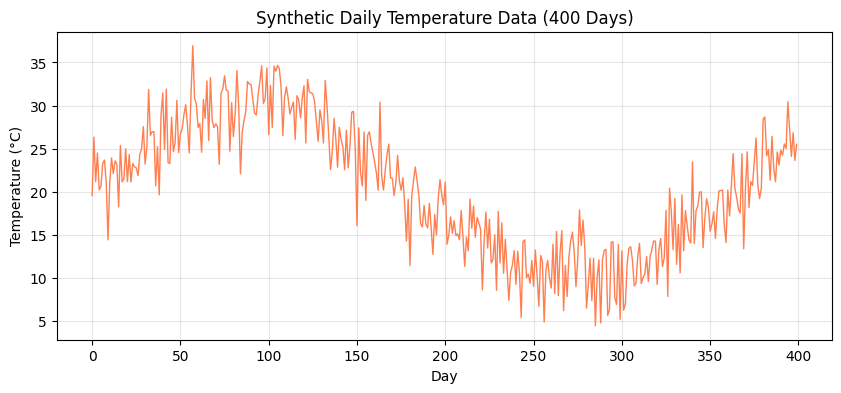

Temperature range: 4.5°C — 36.9°C


In [ ]:
# Generate synthetic weather data (DO NOT MODIFY)
np.random.seed(99)
n_days = 400
day_indices = np.arange(n_days)
# Seasonal pattern (sinusoidal) + trend + noise
temps = 20 + 10 * np.sin(2 * np.pi * day_indices / 365) + np.random.randn(n_days) * 3

plt.figure(figsize=(10, 4))
plt.plot(temps, color='coral', linewidth=1)
plt.title("Synthetic Daily Temperature Data (400 Days)")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()
print(f"Temperature range: {temps.min():.1f}°C — {temps.max():.1f}°C")

### Task 1.1: Prepare Sequence Data
1. Normalize the temperature values to the range [0, 1] using `MinMaxScaler`.
2. Create sliding window sequences: use the previous **14 days** to predict the **next day's** temperature.
3. Reshape the sequences for LSTM input: `(samples, 14, 1)`.
4. Split into training (first 80%) and test (remaining 20%) sets.

**Hint:** Follow the same pattern used in the Lecture notebook's stock prediction case study.

In [ ]:


WINDOW_SIZE = 14

# Normalize prices to [0, 1] using Min-Max scaling
temp_scaler = MinMaxScaler()
temp_scaled = temp_scaler.fit_transform(day_indices.reshape(-1, 1)).flatten()

# Create sliding window sequences
X_temp, y_temp = [], []
for i in range(WINDOW_SIZE, len(temp_scaled)):
    X_temp.append(temp_scaled[i - WINDOW_SIZE:i])
    y_temp.append(temp_scaled[i])

X_temp = np.array(X_temp)
y_temp = np.array(y_temp)

# Reshape for LSTM: (samples, time_steps, features)
X_temp = X_temp.reshape(X_temp.shape[0], WINDOW_SIZE, 1)

In [ ]:
#split into train/test (first 80% for training)

split = int(len(X_temp) * 0.8)
X_train_t, X_test_t = X_temp[:split], X_temp[split:]
y_train_t, y_test_t = y_temp[:split], y_temp[split:]

print(f"Training sequences: {X_train_t.shape}")
print(f"Test sequences: {X_test_t.shape}")
print(f"Each sequence: {WINDOW_SIZE} days -> predict day {WINDOW_SIZE+1}")

Training sequences: (308, 14, 1)
Test sequences: (78, 14, 1)
Each sequence: 14 days -> predict day 15


In [ ]:
#Build and train the LSTM model

model_temp = Sequential([
    LSTM(32, activation= 'tanh', input_shape=(WINDOW_SIZE, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)       #single output: predicted next-day price
])

model_temp.compile(optimizer='adam', loss='mean_squared_error')
model_temp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        16,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,003 (82.04 KB)

 Trainable params: 21,003 (82.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Train = model_temp.fit(
    X_train_t, y_train_t,
    epochs = 30,
    batch_size = 16,
    validation_data=(X_test_t, y_test_t),
    verbose = 1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0598 - val_loss: 0.0051
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - val_loss: 5.8247e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0030 - val_loss: 8.0475e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0030 - val_loss: 5.7915e-05
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022 - val_loss: 1.4198e-04
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - val_loss: 2.7810e-04
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0020 - val_loss: 3.8155e-04
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0024 - val_loss: 4.7050e-05
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 5.7090e-04
Epoch 12/30
20/20 ━━━━━━━━━━━━━

In [ ]:
#predict and visualize result

predictions_scaled = model_temp.predict(X_test_t)
predictions = temp_scaler.inverse_transform(predictions_scaled)
actual = temp_scaler.inverse_transform(y_test_t.reshape(-1,1))

plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual Price', color='yellow', linewidth=3)
plt.plot(predictions, label='LSTM Predicted Price', color='red', linewidth=2, linestyle='--')
plt.title("LSTM Stock Price Prediction: Actual vs. Prediction")
plt.xlabel("Test Day")
plt.ylabel("Stock Price $")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

mse_stock = mean_squared_error(actual, predictions)
print(f"Test MSE: (mse_stock:.4f)")
print(f"Test RMSE: $(np.sqrt(mse_stock):.2f)")